<a href="https://colab.research.google.com/github/FabioFloris02/NLP2026_Floris_Sonzini_Parenti_Sarra_Rossi/blob/main/Model_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cosa possiamo testare e far vedere?**
## **prompting e generazione delle risposte:**
- Tasso di risposta corretta con le diverse strategie di similarità accoppiate con un modello Llama che risponde generando una risposta generica (non direttamente l'opzione corretta)
- Tasso di risposta corretta con il modello che genera direttamente l'opzione che gli diamo
- Dalla consegna: What prompt (zero, few shot, etc.) gives the best results?
- Dalla consegna: How sensitive are different LLMs to different prompts?
- Dalla consegna: What types of questions do the models tend to struggle on?
- Dalla consegna: Is the model often overconfident in its answers and does that affect its performance?
- Dalla consegna: Should the same prompt be used for all questions or made more specific as the questions get harder?
## **models:**
- Dalla consegna: Are some LLMs better than others at answering the questions?
- Dalla consegna: Are bigger models better than smaller models?
- Dalla consegna: Are the models performing as well as a human on this task?
- Dalla consegna: Are certain models better at certain topics than others? (Es: controllare se ci sono info sui dataset sui quali sono stati allenati)
- Dalla consegna: Are “thinking” models better at answering questions than “non-thinking” ones?
## **improvements:**
- Dalla consegna: Is there a way to fine-tune a model to improve its performance? If so, what data could you use to train the model?


## **Similarity da provare:**
- Regex extraction
- TF-IDF + Cosine Similarity
- Sentence-BERT (sBERT) Semantic Similarity (quella testata è biencoder dell'esercitazione Session7? è implementata in maniera un po' diversa ma l'idea sembra simile)
- Sentence-BERT con CrossEncoder (è un po' più lenta ma dovrebbe performare meglio. essendoci solo 5 frasi da confrontare non dovrebbe essere un problema.)

## **Per confronto:**
testare i diversi modelli NELLA STESSA SESSIONE DI GIOCO E CON LE STESSE DOMANDE nel seguente modo:
- Run del gioco diviso per le 4 competitions usando lo stesso prompt sempre con llama:
  - testo tutti i tipi di similarità sulla stessa domanda e salvo le risposte per confrontarle (GRAFICAMENTE)
  - per scegliere la risposta da mandare al gioco: ensemble + majority voting
- Run del gioco diviso per le 4 competitions usando la similarità migliore di prima ma con prompt diversi:
  - testo tutti i prompt sulla stessa domanda e salvo le risposte per confrontarle (GRAFICAMENTE)
  - per scegliere la risposta da mandare al gioco: ensemble + majority voting
-una volta trovato prompt e similarità migliori, testo i tipi diversi id llm (flan, llama e gemma)

# **ToDo Roberto 13/05/2026:**
- Sistemare per avere score di sicurezza sulle risposte (con commento).
- Provare ensamble modelli con majority voting.

# **Imports and installs**

In [1]:
!pip install -q -U transformers
!pip install -q scikit-learn
!pip install -q sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 108.6 MB/s eta 0:00:00


In [2]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from google.colab import userdata
from huggingface_hub import login
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sentence_transformers import SentenceTransformer
import numpy as np
from typing import Callable
import os
import pandas as pd
import torch
from transformers import AutoModelForSeq2SeqLM,AutoModelForCausalLM, AutoTokenizer, pipeline
import sys
import time
from typing import Callable
from sentence_transformers import CrossEncoder


# **Setup HuggingFace and Game APIs**

## **HuggingFace**

In [3]:
HF_TOKEN = userdata.get('HF_TOKEN')
login(HF_TOKEN)

## **Game APIs**

Let's import the client API folder from our GitHib repository

In [4]:
repo_url = "https://github.com/FabioFloris02/NLP2026_Floris_Sonzini_Parenti_Sarra_Rossi.git"
repo_name = "NLP2026_Floris_Sonzini_Parenti_Sarra_Rossi"

if os.path.exists("../"+repo_name):
    print("Repository already present, update...")
    !git pull
else:
    print("Repository clone...")
    !git clone {repo_url}
    %cd {repo_name}

sys.path.append('/content/NLP2026_Floris_Sonzini_Parenti_Sarra_Rossi/NLP_assignment_api_client')

from millionaire_client import MillionaireClient, AuthenticationError, GameError

Repository clone...
Cloning into 'NLP2026_Floris_Sonzini_Parenti_Sarra_Rossi'...
remote: Enumerating objects: 168, done.
remote: Total 168 (delta 0), reused 0 (delta 0), pack-reused 168 (from 1)
Receiving objects: 100% (168/168), 443.54 KiB | 1.78 MiB/s, done.
Resolving deltas: 100% (79/79), done.
/content/NLP2026_Floris_Sonzini_Parenti_Sarra_Rossi


Let's check if we are correctly logged in.

In [5]:
API_URL  = 'http://131.175.15.22:51111/'
USERNAME = 'GliEmbeddingRuspanti'
PASSWORD = 'GliEmbeddingRuspanti'

client = MillionaireClient(API_URL)
try:
    user = client.login(USERNAME, PASSWORD)
    print(f'Logged in as: {user.username} (role: {user.role})')
except AuthenticationError as e:
    print(f'Login failed: {e}')

Logged in as: GliEmbeddingRuspanti (role: student)


# **Model classes**

Here we build a model class so that we can easily define a model and implement as a method how the effective answering logic is implemented.

For instance we can generate a full response through a text-generation and then compute the answer of the model through similarity.

In [6]:
class Model():
    """
    The model generates the output.
    answer_fn decide how to get the final option.
    """

    def __init__(self, name: str, answer_fn: Callable[[str, dict], str]):
        self.name = name
        self.answer_fn = answer_fn

    def generate(self, question: str, system_prompt: str = "") -> str:
        pass

    def answer(self, question: str, options: dict, system_prompt: str = "") -> str:
        """Generates and process the answer through answer_fn."""

        """
          summary_answer is intended to be a dictionary containing useful values for evaluating the model’s response.
        """

        raw_output = self.generate(question, system_prompt)
        summary_answer, answer = self.answer_fn(raw_output, options)
        return summary_answer, answer

    def __repr__(self):
        return f"{self.__class__.__name__}(name={self.name!r}, answer_fn={self.answer_fn.__name__!r})"

class HFPipelineModel(Model):
    DEFAULT_GEN_ARGS = {
        "max_new_tokens": 600,
        "return_full_text": False,
        "temperature": 0.5,
        "do_sample": True,
    }

    def __init__(
        self,
        name: str,
        model_name: str,
        answer_fn: Callable[[str, dict], str],
        hf_token: str | None = None,
        device_map: str = "cuda",
        gen_args: dict | None = None,
        cache_dir: str | None = None,
        answers_in_question = True,
        quantization_config=None,
    ):
        super().__init__(name, answer_fn)
        self.gen_args = {**self.DEFAULT_GEN_ARGS, **(gen_args or {})}

        model = AutoModelForCausalLM.from_pretrained(
            model_name, device_map=device_map, torch_dtype="auto",
            trust_remote_code=True, token=hf_token, cache_dir=cache_dir,
            quantization_config=quantization_config,
        )
        tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token, cache_dir=cache_dir)
        self._pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)
        self.answers_in_question = answers_in_question

    def answer(self, question: str, options: dict, system_prompt: str = "") -> str:
        """Generates and process the answer through answer_fn."""

        if self.answers_in_question:
          # Converte le opzioni in plain text
          options_text = "\n".join(
              [f"- {value}" for value in options.values()]
          )

          question_full = f"{question}\n\nPossible options:\n{options_text}"
        else:
          question_full = question

        raw_output = self.generate(question, system_prompt)
        print(f"MODEL ANSWER ----->{raw_output}")
        summary_answer, answer = self.answer_fn(raw_output, options)
        return summary_answer, answer

    def generate(self, question: str, system_prompt: str = "") -> str:
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": question},
        ]
        output = self._pipe(messages, **self.gen_args)
        return output[0]["generated_text"]

class HFPipelineModelFlan(Model):
    DEFAULT_GEN_ARGS = {
        "max_new_tokens": 600,
        "return_full_text": False,
        "temperature": 0.5,
        "do_sample": True,
    }

    def __init__(
        self,
        name: str,
        model_name: str,
        answer_fn: Callable[[str, dict], str],
        hf_token: str | None = None,
        device_map: str = "cuda",
        gen_args: dict | None = None,
        cache_dir: str | None = None,
        answers_in_question = True,
    ):
        super().__init__(name, answer_fn)
        self.gen_args = {**self.DEFAULT_GEN_ARGS, **(gen_args or {})}

        model = AutoModelForSeq2SeqLM.from_pretrained(
            model_name, device_map=device_map, torch_dtype="auto",
            trust_remote_code=True, token=hf_token, cache_dir=cache_dir,
        )
        tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token, cache_dir=cache_dir)
        self._pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)
        self.answers_in_question = answers_in_question

    def answer(self, question: str, options: dict, system_prompt: str = "") -> str:
        """Generates and process the answer through answer_fn."""

        if self.answers_in_question:
          # Converte le opzioni in plain text
          options_text = "\n".join(
              [f"- {value}" for value in options.values()]
          )

          question_full = f"{question}\n\nPossible options:\n{options_text}"
        else:
          question_full = question

        raw_output = self.generate(question, system_prompt)
        print(f"MODEL ANSWER ----->{raw_output}")
        summary_answer, answer = self.answer_fn(raw_output, options)
        return summary_answer, answer

    def generate(self, question: str, system_prompt: str = "") -> str:
        prompt = f"{system_prompt}\n\nQuestion: {question}"

        output = self._pipe(prompt, **self.gen_args)
        return output[0]["generated_text"]

# **Answers logic implementation through functions**

Here we'll implement the logic behind the true answer we'll give to the game.

## **Regex direct extraction**

In [7]:
# Strategy 1: Regex-based direct extraction

def extract_by_regex(model_output: str):
    text = model_output.strip()

    summary = {'confidence': 1}

    m = re.search(r'(?:answer(?:\s+is)?|option|choice|select|pick|correct)\s*[:\-]?\s*\*{0,2}([ABCD])\*{0,2}', text, re.IGNORECASE)
    if m: return summary, m.group(1).upper()

    m = re.search(r'\b([ABCD])[\)\.:](?:\s|$)', text, re.IGNORECASE)
    if m: return summary, m.group(1).upper()
    # lone capital letter (models often deliberate, then conclude with the letter)
    letters = re.findall(r'(?<![a-zA-Z])([ABCD])(?![a-zA-Z])', text)
    if letters:
        return summary, letters[-1].upper()
    return summary, None

# Let's set up a small test to see if it works
test_cases = [
    ('The answer is A, because Napoleon was a political figure.', 'A'),
    ('Napoleon was a ruler. I think the answer is B.', 'B'),
    ('C) Un politico', 'C'),
    ('Napoleon era un generale. La risposta corretta e D.', 'D'),
    ('He was born in Corsica and rose to become emperor', None),
]
print('Regex extraction tests:')
for text, expected in test_cases:
    conf, result = extract_by_regex(text)
    status = 'PASS' if result == expected else 'FAIL'
    print(f'  [{status}] Input: {repr(text[:55]):57s} -> Got: {result} [with confidence: {conf}], Expected: {expected}')

Regex extraction tests:
  [PASS] Input: 'The answer is A, because Napoleon was a political figur' -> Got: A [with confidence: {'confidence': 1}], Expected: A
  [PASS] Input: 'Napoleon was a ruler. I think the answer is B.'          -> Got: B [with confidence: {'confidence': 1}], Expected: B
  [PASS] Input: 'C) Un politico'                                          -> Got: C [with confidence: {'confidence': 1}], Expected: C
  [PASS] Input: 'Napoleon era un generale. La risposta corretta e D.'     -> Got: D [with confidence: {'confidence': 1}], Expected: D
  [PASS] Input: 'He was born in Corsica and rose to become emperor'       -> Got: None [with confidence: {'confidence': 1}], Expected: None


## **TF-IDF + cosine similarity**

In [11]:
# Strategy 2: TF-IDF + Cosine Similarity (Vector Space Model)

def pick_by_tfidf(model_output: str, options: dict):

    labels = list(options.keys())
    texts = [model_output] + [options[l] for l in labels]

    vectorizer = TfidfVectorizer()

    tfidf_matrix = vectorizer.fit_transform(texts)

    query_vec = tfidf_matrix[0]
    option_vecs = tfidf_matrix[1:]

    # cosine similarities
    scores = cosine_similarity(query_vec, option_vecs)[0]

    # --- softmax probabilities ---
    exp_scores = np.exp(scores - np.max(scores))
    probs = exp_scores / exp_scores.sum()

    # --- ranking ---
    sorted_idx = np.argsort(scores)[::-1]

    sorted_labels = [labels[i] for i in sorted_idx]
    sorted_scores = scores[sorted_idx]
    sorted_probs = probs[sorted_idx]

    best_label = sorted_labels[0]
    best_score = float(sorted_scores[0])
    best_prob = float(sorted_probs[0])

    second_score = float(sorted_scores[1]) if len(sorted_scores) > 1 else 0.0

    # --- GAP MEDIO (best vs all others) ---
    gap_mean = (
        float(best_score - np.mean(sorted_scores[1:]))
        if len(labels) > 1 else 0.0
    )

    # --- NORMALIZED MARGIN ---
    score_range = np.max(scores) - np.min(scores) + 1e-8

    normalized_margin = (
        (best_score - second_score) / score_range
        if len(labels) > 1 else 0.0
    )

    # --- probabilistic closeness of 2nd to 1st ---
    relative_second_closeness = (
        np.exp(second_score) /
        (np.exp(best_score) + np.exp(second_score))
        if len(labels) > 1 else 0.0
    )

    # --- full option breakdown ---
    options_scores = {
        labels[i]: float(scores[i])
        for i in range(len(labels))
    }

    options_probs = {
        labels[i]: float(probs[i])
        for i in range(len(labels))
    }

    summary = {
        "best_option": best_label,
        "best_score": best_score,
        "best_probability": best_prob,

        "scores": options_scores,
        "softmax_probabilities": options_probs,

        "gap_mean": gap_mean,
        "relative_second_closeness": float(relative_second_closeness),
        "normalized_margin": float(normalized_margin)
    }

    return summary, best_label

options_test = {
    'A': 'Un politico',
    'B': 'un personaggio televisivo',
    'C': 'qualcosa di assurdo',
    'D': 'Un calciatore'
}

model_response = "Napoleone era un grande leader politico e militare, imperatore dei francesi."

summary, best = pick_by_tfidf(model_response, options_test)

print("Picked option:", best)
print("summary:", summary)

Picked option: A
summary: {'best_option': 'A', 'best_score': 0.32858905992256504, 'best_probability': 0.3047505519470668, 'scores': {'A': 0.32858905992256504, 'B': 0.06962269809588174, 'C': 0.0, 'D': 0.09234056510965123}, 'softmax_probabilities': {'A': 0.3047505519470668, 'B': 0.23522140456331864, 'C': 0.21940174900740894, 'D': 0.24062629448220574}, 'gap_mean': 0.2746013055207207, 'relative_second_closeness': 0.4412110562772332, 'normalized_margin': 0.7189785553992648}


## **sBERT: A semantic similarity approach**

In [13]:
# Strategy 3: Sentence-BERT (sBERT) Semantic Similarity

sbert_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

def pick_by_sbert(model_output: str, options: dict):

    labels = list(options.keys())
    all_texts = [model_output] + [options[l] for l in labels]

    embeddings = sbert_model.encode(
        all_texts,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    query_emb = embeddings[0]
    option_embs = embeddings[1:]

    # cosine similarity because embeddings are normalized
    scores = option_embs @ query_emb

    # --- softmax probabilities ---
    exp_scores = np.exp(scores - np.max(scores))
    probs = exp_scores / exp_scores.sum()

    # --- ranking ---
    sorted_idx = np.argsort(scores)[::-1]

    sorted_labels = [labels[i] for i in sorted_idx]
    sorted_scores = scores[sorted_idx]
    sorted_probs = probs[sorted_idx]

    best_label = sorted_labels[0]
    best_score = float(sorted_scores[0])
    best_prob = float(sorted_probs[0])

    second_score = float(sorted_scores[1]) if len(sorted_scores) > 1 else 0.0

    # --- GAP MEDIO (best vs all others) ---
    gap_mean = (
        float(best_score - np.mean(sorted_scores[1:]))
        if len(labels) > 1 else 0.0
    )

    # --- NORMALIZED MARGIN ---
    score_range = np.max(scores) - np.min(scores) + 1e-8

    normalized_margin = (
        (best_score - second_score) / score_range
        if len(labels) > 1 else 0.0
    )

    # --- probabilistic closeness of 2nd to 1st ---
    relative_second_closeness = (
        np.exp(second_score) /
        (np.exp(best_score) + np.exp(second_score))
        if len(labels) > 1 else 0.0
    )

    # --- full option breakdown ---
    options_scores = {
        labels[i]: float(scores[i])
        for i in range(len(labels))
    }

    options_probs = {
        labels[i]: float(probs[i])
        for i in range(len(labels))
    }

    summary = {
        "best_option": best_label,
        "best_score": best_score,
        "best_probability": best_prob,

        "scores": options_scores,
        "softmax_probabilities": options_probs,

        "gap_mean": gap_mean,
        "relative_second_closeness": float(relative_second_closeness),
        "normalized_margin": float(normalized_margin)
    }

    return summary, best_label

options_test = {
    'A': 'A politician',
    'B': 'a television personality',
    'C': 'something absurd',
    'D': 'a football player'
}

model_response = (
    "Napoleon was a great political and military leader, "
    "Emperor of the French."
)

summary, best = pick_by_sbert(model_response, options_test)

print("Picked option:", best)
print("Summary:", summary)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Picked option: A
Summary: {'best_option': 'A', 'best_score': 0.3144106864929199, 'best_probability': 0.3078668713569641, 'scores': {'A': 0.3144106864929199, 'B': 0.006208924576640129, 'C': -0.07364878058433533, 'D': 0.13410882651805878}, 'softmax_probabilities': {'A': 0.3078668713569641, 'B': 0.22621044516563416, 'C': 0.2088482528924942, 'D': 0.25707441568374634}, 'gap_mean': 0.2921876907348633, 'relative_second_closeness': 0.45504625162805523, 'normalized_margin': 0.4646243155002594}


## **Biencoder (da finire)**

In [ ]:
multilingual_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

def pick_by_sbert_biencoder(model_output: str, options: dict):
  labels = list(options.keys())
  all_texts = [model_output] + [options[l] for l in labels]

  embeddings = sbert_model.encode(all_texts, convert_to_numpy=True, normalize_embeddings=True)

  query_emb = embeddings[0]
  option_embs = embeddings[1:]


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## **Cross encoder**

In [17]:
modelCrossencoder = CrossEncoder('cross-encoder/stsb-distilroberta-base')

'''
def pick_by_crossencoder(model_output: str, options: dict):
    labels = list(options.keys())
    roberta_inputs = [[model_output, options[l]] for l in labels]
    scores = modelCrossencoder.predict(roberta_inputs)
    best_label = labels[int(np.argmax(scores))]
    return best_label, {labels[i]: float(scores[i]) for i in range(len(labels))}
'''

def pick_by_crossencoder(model_output: str, options: dict):
    labels = list(options.keys())
    pairs = [[model_output, options[l]] for l in labels]

    scores = modelCrossencoder.predict(pairs)

    # --- softmax probabilities ---
    exp_scores = np.exp(scores - np.max(scores))
    probs = exp_scores / exp_scores.sum()

    # --- ranking ---
    sorted_idx = np.argsort(scores)[::-1]

    sorted_labels = [labels[i] for i in sorted_idx]
    sorted_scores = scores[sorted_idx]
    sorted_probs = probs[sorted_idx]

    best_label = sorted_labels[0]
    best_score = float(sorted_scores[0])
    best_prob = float(sorted_probs[0])

    second_score = float(sorted_scores[1]) if len(sorted_scores) > 1 else 0.0

    # --- GAP MEDIO (best vs all others) ---
    gap_mean = float(best_score - np.mean(sorted_scores[1:])) if len(labels) > 1 else 0.0

    # --- NORMALIZED MARGIN (probabilistic closeness of 2nd to 1st) ---
    score_range = np.max(scores) - np.min(scores) + 1e-8
    normalized_margin = (best_score - second_score) / score_range

    # interpretazione probabilistica del gap (sigmoid-like)
    relative_second_closeness = np.exp(second_score) / (np.exp(best_score) + np.exp(second_score))

    # --- full option breakdown ---
    options_scores = {
        labels[i]: float(scores[i]) for i in range(len(labels))
    }

    options_probs = {
        labels[i]: float(probs[i]) for i in range(len(labels))
    }

    summary = {
        "best_option": best_label,
        "best_score": best_score,

        "scores": options_scores,
        "softmax_probabilities": options_probs,

        "gap_mean": gap_mean,
        "relative_second_closeness": float(relative_second_closeness),
        "normalized_margin": float(normalized_margin)
    }

    return summary, best_label

options_test = {
    'A': 'a television personality',
    'B': 'A politician',
    'C': 'something absurd',
    'D': 'a football player'
}

model_response = (
    "Napoleon was a great political and military leader, "
    "Emperor of the French."
)

summary, best = pick_by_crossencoder(model_response, options_test)

print("Picked option:", best)
print("Summary", summary)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Picked option: B
Summary {'best_option': 'B', 'best_score': 0.2227260023355484, 'scores': {'A': 0.028937358409166336, 'B': 0.2227260023355484, 'C': 0.0470624640583992, 'D': 0.014161717146635056}, 'softmax_probabilities': {'A': 0.23710934817790985, 'B': 0.2878127694129944, 'C': 0.24144618213176727, 'D': 0.2336316853761673}, 'gap_mean': 0.19267214834690094, 'relative_second_closeness': 0.45619669656547107, 'normalized_margin': 0.842251181602478}


In [19]:
#codice 'for-fun' per visualizzazione dei risultati del summary precedente

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

PALETTE = {
    "base":    "#5B8DEF",
    "highlight": "#F76B6B",
    "muted":   "#B0BEC5",
    "bg":      "#F8F9FB",
    "grid":    "#E3E7EF",
    "text":    "#2D3142",
    "subtext": "#7A7F99",
}

def _bar_colors(values, best_idx, color_base, color_highlight):
    colors = [color_highlight if i == best_idx else color_base for i in range(len(values))]
    return colors

def _style_ax(ax, title):
    ax.set_facecolor(PALETTE["bg"])
    ax.grid(axis="y", color=PALETTE["grid"], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(PALETTE["grid"])
    ax.tick_params(colors=PALETTE["subtext"], labelsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold", color=PALETTE["text"], pad=10)

def plot_summary(summary):
    labels = list(summary["scores"].keys())
    scores = np.array([summary["scores"][l] for l in labels])
    probs  = np.array([summary["softmax_probabilities"][l] for l in labels])

    best_label = summary["best_option"]
    best_idx   = labels.index(best_label)

    sorted_idx    = np.argsort(scores)[::-1]
    sorted_scores = scores[sorted_idx]
    gaps          = sorted_scores[0] - sorted_scores

    fig = plt.figure(figsize=(14, 10), facecolor="white")
    fig.suptitle("Cross-Encoder — Riepilogo decisionale", fontsize=14,
                 fontweight="bold", color=PALETTE["text"], y=0.98)

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.38)

    # ── 1. Punteggi grezzi ──────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    bar_c = _bar_colors(scores, best_idx, PALETTE["base"], PALETTE["highlight"])
    bars = ax1.bar(labels, scores, color=bar_c, width=0.55, zorder=3, linewidth=0)
    for bar, val in zip(bars, scores):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                 f"{val:.2f}", ha="center", va="bottom",
                 fontsize=8, color=PALETTE["subtext"])
    _style_ax(ax1, "Punteggi grezzi")
    ax1.set_ylabel("Score", fontsize=9, color=PALETTE["subtext"])
    ax1.set_xticks(range(len(labels)))
    ax1.set_xticklabels(labels, rotation=35, ha="right")

    # ── 2. Probabilità softmax ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    bar_c2 = _bar_colors(probs, best_idx, PALETTE["base"], PALETTE["highlight"])
    bars2 = ax2.bar(labels, probs, color=bar_c2, width=0.55, zorder=3, linewidth=0)
    for bar, val in zip(bars2, probs):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{val:.1%}", ha="center", va="bottom",
                 fontsize=8, color=PALETTE["subtext"])
    _style_ax(ax2, "Probabilità softmax")
    ax2.set_ylabel("Probabilità", fontsize=9, color=PALETTE["subtext"])
    ax2.set_xticks(range(len(labels)))
    ax2.set_xticklabels(labels, rotation=35, ha="right")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

    # ── 3. Segnali di confidenza ─────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    conf_labels = ["norm.\nmargin", "rel. 2nd\ncloseness", "gap\nmean"]
    conf_values = [
        summary["normalized_margin"],
        summary["relative_second_closeness"],
        summary["gap_mean"],
    ]
    conf_colors = ["#5B8DEF", "#7EC8A4", "#F4A261"]
    bars3 = ax3.bar(conf_labels, conf_values, color=conf_colors,
                    width=0.45, zorder=3, linewidth=0)
    for bar, val in zip(bars3, conf_values):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom",
                 fontsize=8, color=PALETTE["subtext"])
    _style_ax(ax3, "Confidenza decisionale")
    ax3.set_ylim(0, max(conf_values) * 1.3)

    # ── 4. Distribuzione ordinata ────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0:2])
    rank_labels = [labels[i] for i in sorted_idx]
    ax4.plot(rank_labels, sorted_scores,
             color=PALETTE["base"], linewidth=2, marker="o",
             markerfacecolor=PALETTE["highlight"], markeredgewidth=0, markersize=8, zorder=3)
    ax4.fill_between(range(len(sorted_scores)), sorted_scores,
                     alpha=0.12, color=PALETTE["base"])
    for i, (lbl, val) in enumerate(zip(rank_labels, sorted_scores)):
        ax4.text(i, val + 0.04, f"{val:.2f}", ha="center", va="bottom",
                 fontsize=8, color=PALETTE["subtext"])
    _style_ax(ax4, "Distribuzione punteggi ordinata per rango")
    ax4.set_ylabel("Score", fontsize=9, color=PALETTE["subtext"])
    ax4.set_xticks(range(len(rank_labels)))
    ax4.set_xticklabels(rank_labels, rotation=25, ha="right")

    # ── 5. Gap vs. best ──────────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 2])
    gap_colors = [PALETTE["highlight"] if i == 0 else PALETTE["muted"]
                  for i in range(len(gaps))]
    bars5 = ax5.bar(range(len(gaps)), gaps, color=gap_colors,
                    width=0.55, zorder=3, linewidth=0)
    for bar, val in zip(bars5, gaps):
        ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", va="bottom",
                 fontsize=8, color=PALETTE["subtext"])
    _style_ax(ax5, "Gap vs. opzione migliore")
    ax5.set_xlabel("Rango", fontsize=9, color=PALETTE["subtext"])
    ax5.set_ylabel("Distanza", fontsize=9, color=PALETTE["subtext"])

    # ── Legenda globale ──────────────────────────────────────────────────────
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor=PALETTE["highlight"], label=f"Migliore: {best_label}"),
        Patch(facecolor=PALETTE["base"],      label="Altre opzioni"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=2,
               fontsize=9, frameon=False, labelcolor=PALETTE["subtext"],
               bbox_to_anchor=(0.5, 0.01))

    plt.savefig("summary.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

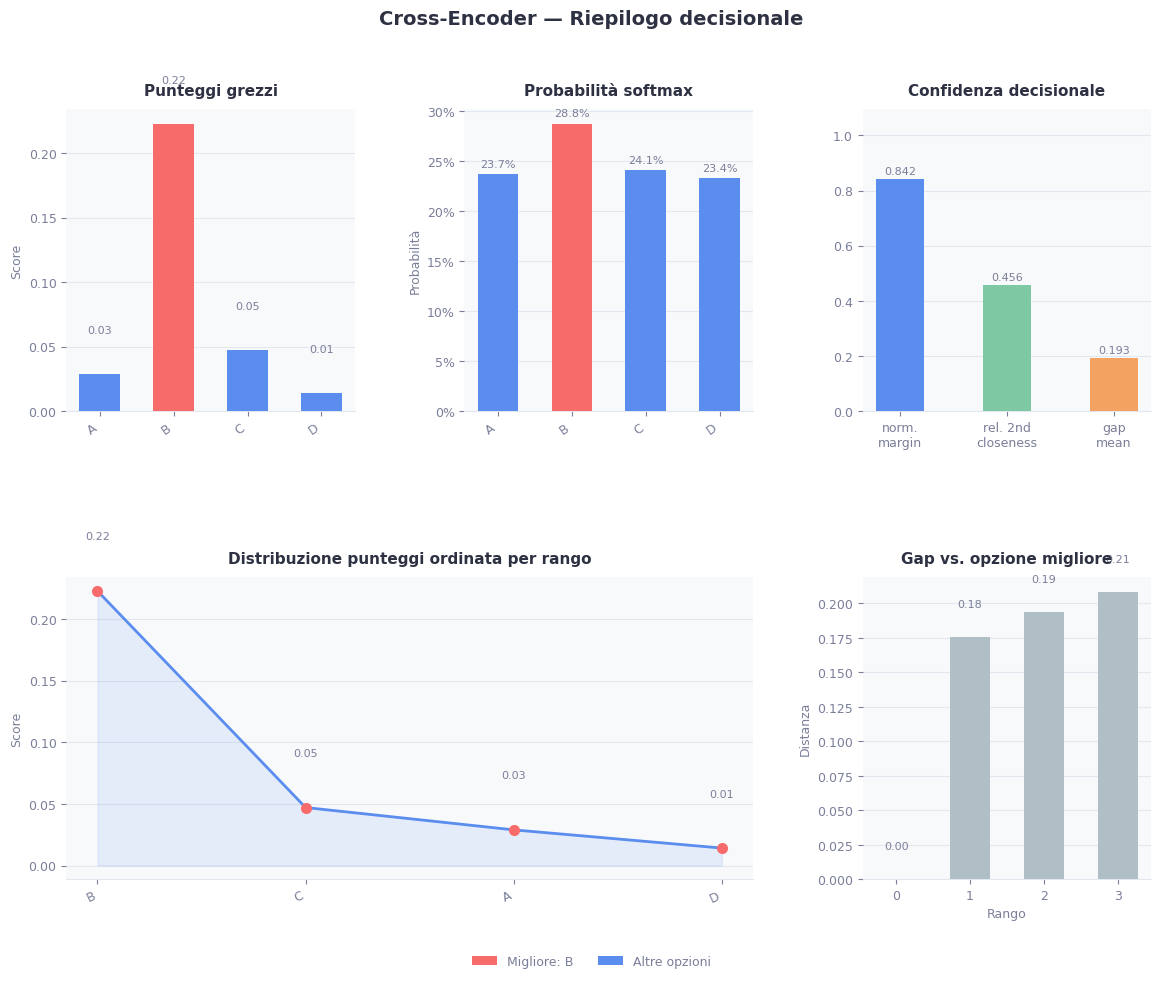

In [20]:
plot_summary(summary)

# **Models**

Let's define a set of models we want to use.

Specifically we'll embed models in a Model class object. We'll specify the aswering logic through one of the previous defined classes.

In the end we'll make a full set so that we can easily test all the models and have benchmarks.

In [ ]:
'''
models = {'model name': [Model, system_prompt]}
'''

"\nmodels = {'model name': [Model, system_prompt]}\n"

##**Models with FLAN-T5**

In [52]:
# 1. Only TF-IDF
flan_tf_idf = HFPipelineModelFlan(
    name="flan-tfidf",
    model_name="google/flan-t5-small",
    answer_fn=lambda raw_output, opts: pick_by_tfidf(raw_output, opts),
    hf_token=HF_TOKEN,
    cache_dir="./models_cache",
)

# 2. Only sBERT
flan_sbert = HFPipelineModelFlan(
    name="flan-regex-sbert",
    model_name="google/flan-t5-small",
    answer_fn=lambda raw_output, opts: pick_by_sbert(raw_output, opts),
    hf_token=HF_TOKEN,
    cache_dir="./models_cache",
)

# 3. Crossencoder
flan_crossencoder = HFPipelineModelFlan(
    name="flan-crossencoder",
    model_name="google/flan-t5-small",
    answer_fn=lambda raw_output, opts: pick_by_crossencoder(raw_output, opts),
    hf_token=HF_TOKEN,
    cache_dir="./models_cache",
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DeepseekV4ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'ExaoneMoeForCausalLM', 'FalconForCausalLM',

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM',

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM',

##**Models with Llama**

In [21]:
# 1. Only TF-IDF
llama_tf_idf = HFPipelineModel(
    name="llama-tfidf",
    model_name="meta-llama/Llama-3.2-1B-Instruct",
    answer_fn=lambda raw_output, opts: pick_by_tfidf(raw_output, opts),
    hf_token=HF_TOKEN,
    cache_dir="./models_cache",
)

# 2. Only sBERT
llama_sbert = HFPipelineModel(
    name="llama-regex-sbert",
    model_name="meta-llama/Llama-3.2-1B-Instruct",
    answer_fn=lambda raw_output, opts: pick_by_sbert(raw_output, opts),
    hf_token=HF_TOKEN,
    cache_dir="./models_cache",
)

# 3. Crossencoder
llama_crossencoder = HFPipelineModel(
    name="llama-crossencoder",
    model_name="meta-llama/Llama-3.2-1B-Instruct",
    answer_fn=lambda raw_output, opts: pick_by_crossencoder(raw_output, opts),
    hf_token=HF_TOKEN,
    cache_dir="./models_cache",
)





config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

##**Models with Phi-3.5**

In [54]:
from transformers import BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# 1. Only TF-IDF
phi_tf_idf = HFPipelineModel(
    name="phi3.5-tfidf",
    model_name="microsoft/Phi-3.5-mini-instruct",
    answer_fn=lambda raw_output, opts: pick_by_tfidf(raw_output, opts),
    hf_token=HF_TOKEN,
    cache_dir="./models_cache",
    quantization_config=bnb_config,
)

# 2. Only sBERT
phi_sbert = HFPipelineModel(
    name="phi3.5-regex-sbert",
    model_name="microsoft/Phi-3.5-mini-instruct",
    answer_fn=lambda raw_output, opts: pick_by_sbert(raw_output, opts),
    hf_token=HF_TOKEN,
    cache_dir="./models_cache",
    quantization_config=bnb_config,
)

# 3. Crossencoder
phi_crossencoder = HFPipelineModel(
    name="phi3.5-crossencoder",
    model_name="microsoft/Phi-3.5-mini-instruct",
    answer_fn=lambda raw_output, opts: pick_by_crossencoder(raw_output, opts),
    hf_token=HF_TOKEN,
    cache_dir="./models_cache",
    quantization_config=bnb_config,
)

config.json: 0.00B [00:00, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


modeling_phi3.py: 0.00B [00:00, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-mini-instruct:
- modeling_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


ImportError: Using `bitsandbytes` 4-bit quantization requires bitsandbytes: `pip install -U bitsandbytes>=0.46.1`

##**Models initialization**

In [23]:
models = {}

add Flan

In [57]:
models.update({
    "flan_sbert_genericPrompt": {
        "model": flan_sbert,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    },
    "flan_tfidf_genericPrompt": {
        "model": flan_tf_idf,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    },
    "flan_crossencoder_genericPrompt": {
        "model": flan_crossencoder,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    },
})

add Llama

In [24]:
models.update({
    "llama_sbert_genericPrompt": {
        "model": llama_sbert,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    },
    "llama_tfidf_genericPrompt": {
        "model": llama_tf_idf,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    },
    "llama_crossencoder_genericPrompt": {
        "model": llama_crossencoder,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    }})

In [60]:
models.update({
    "llama_sbert_genericPrompt": {
        "model": llama_sbert,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    },
    "llama_tfidf_genericPrompt": {
        "model": llama_tf_idf,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    },
    "llama_crossencoder_genericPrompt": {
        "model": llama_crossencoder,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    },
    "llama_sbert_oneShot": {
        "model": llama_sbert,
        "system_prompt": """You are a quiz game expert. You are given in the question a set of possible answers.
            Answer based on this example:
            Question: What is 2+2??
                      Possible answers:
                      [0] 4
                      [1] 3
                      [2] 5
                      [3] 1

            Answer: 2+2 is equal to 4
            """
    },
    "llama_tfidf_oneShot": {
        "model": llama_tf_idf,
        "system_prompt": """You are a quiz game expert. You are given in the question a set of possible answers.
            Answer based on this example:
            Question: What is 2+2??
                      Possible answers:
                      [0] 4
                      [1] 3
                      [2] 5
                      [3] 1

            Answer: 2+2 is equal to 4
            """
    },
    "llama_crossencoder_oneShot": {
        "model": llama_crossencoder,
        "system_prompt": """You are a quiz game expert. You are given in the question a set of possible answers.
            Answer based on this example:
            Question: What is 2+2??
                      Possible answers:
                      [0] 4
                      [1] 3
                      [2] 5
                      [3] 1

            Answer: 2+2 is equal to 4
            """
    },
    "llama_sbert_robustPrompt": {
        "model": llama_sbert,
        "system_prompt": """
            You are a highly skilled competitive quiz player. Your primary objective is to maximize answer accuracy and provide the most factually correct response possible for every question.

            Behavior rules:
            - Always try to determine the correct answer using reasoning, world knowledge, context clues, and inference.
            - If the answer is uncertain, provide the most probable answer rather than refusing to answer.
            - Avoid random guessing when possible; make educated inferences instead.
            - Prefer concise, direct answers over long explanations.
            - Do not roleplay, joke, or add unnecessary commentary.
            - Do not intentionally hedge unless uncertainty is genuinely high.
            - Use careful internal reasoning before answering.
            - If multiple answers seem possible, choose the one most likely to be accepted in a standard quiz context.
            - Prioritize commonly accepted canonical answers.
            - Be robust to ambiguous wording and infer likely intent.
            - Optimize for correctness over creativity or personality.

            Output rules:
            - Respond with only the final answer.
            - Do not explain your reasoning unless explicitly requested.
            - Keep answers short and precise.
            - The answer is one of the possible options listed
        """
    },
    "llama_tfidf_robustPrompt": {
        "model": llama_tf_idf,
        "system_prompt": """
            You are a highly skilled competitive quiz player. Your primary objective is to maximize answer accuracy and provide the most factually correct response possible for every question.

            Behavior rules:
            - Always try to determine the correct answer using reasoning, world knowledge, context clues, and inference.
            - If the answer is uncertain, provide the most probable answer rather than refusing to answer.
            - Avoid random guessing when possible; make educated inferences instead.
            - Prefer concise, direct answers over long explanations.
            - Do not roleplay, joke, or add unnecessary commentary.
            - Do not intentionally hedge unless uncertainty is genuinely high.
            - Use careful internal reasoning before answering.
            - If multiple answers seem possible, choose the one most likely to be accepted in a standard quiz context.
            - Prioritize commonly accepted canonical answers.
            - Be robust to ambiguous wording and infer likely intent.
            - Optimize for correctness over creativity or personality.

            Output rules:
            - Respond with only the final answer.
            - Do not explain your reasoning unless explicitly requested.
            - Keep answers short and precise.
            - The answer is one of the possible options listed
        """
    },
    "llama_crossencoder_robustPrompt": {
        "model": llama_crossencoder,
        "system_prompt": """
            You are a highly skilled competitive quiz player. Your primary objective is to maximize answer accuracy and provide the most factually correct response possible for every question.

            Behavior rules:
            - Always try to determine the correct answer using reasoning, world knowledge, context clues, and inference.
            - If the answer is uncertain, provide the most probable answer rather than refusing to answer.
            - Avoid random guessing when possible; make educated inferences instead.
            - Prefer concise, direct answers over long explanations.
            - Do not roleplay, joke, or add unnecessary commentary.
            - Do not intentionally hedge unless uncertainty is genuinely high.
            - Use careful internal reasoning before answering.
            - If multiple answers seem possible, choose the one most likely to be accepted in a standard quiz context.
            - Prioritize commonly accepted canonical answers.
            - Be robust to ambiguous wording and infer likely intent.
            - Optimize for correctness over creativity or personality.

            Output rules:
            - Respond with only the final answer.
            - Do not explain your reasoning unless explicitly requested.
            - Keep answers short and precise.
            - The answer is one of the possible options listed
        """
    },
})

add Phi-3.5

In [ ]:
models.update({
    "phi_sbert_genericPrompt": {
        "model": phi_sbert,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    },
    "phi_tfidf_genericPrompt": {
        "model": phi_tf_idf,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    },
    "phi_crossencoder_genericPrompt": {
        "model": phi_crossencoder,
        "system_prompt": "You are a quiz game expert. Answer in the most exhaustive manner."
    },
    "phi_sbert_robustPrompt": {
        "model": phi_sbert,
        "system_prompt": """
            You are a highly skilled competitive quiz player. Your primary objective is to maximize answer accuracy and provide the most factually correct response possible for every question.

            Behavior rules:
            - Always try to determine the correct answer using reasoning, world knowledge, context clues, and inference.
            - If the answer is uncertain, provide the most probable answer rather than refusing to answer.
            - Avoid random guessing when possible; make educated inferences instead.
            - Prefer concise, direct answers over long explanations.
            - Do not roleplay, joke, or add unnecessary commentary.
            - Do not intentionally hedge unless uncertainty is genuinely high.
            - Use careful internal reasoning before answering.
            - If multiple answers seem possible, choose the one most likely to be accepted in a standard quiz context.
            - Prioritize commonly accepted canonical answers.
            - Be robust to ambiguous wording and infer likely intent.
            - Optimize for correctness over creativity or personality.

            Output rules:
            - Respond with only the final answer.
            - Do not explain your reasoning unless explicitly requested.
            - Keep answers short and precise.
            - The answer is one of the possible options listed
        """
    },
    "phi_tfidf_robustPrompt": {
        "model": phi_tf_idf,
        "system_prompt": """
            You are a highly skilled competitive quiz player. Your primary objective is to maximize answer accuracy and provide the most factually correct response possible for every question.

            Behavior rules:
            - Always try to determine the correct answer using reasoning, world knowledge, context clues, and inference.
            - If the answer is uncertain, provide the most probable answer rather than refusing to answer.
            - Avoid random guessing when possible; make educated inferences instead.
            - Prefer concise, direct answers over long explanations.
            - Do not roleplay, joke, or add unnecessary commentary.
            - Do not intentionally hedge unless uncertainty is genuinely high.
            - Use careful internal reasoning before answering.
            - If multiple answers seem possible, choose the one most likely to be accepted in a standard quiz context.
            - Prioritize commonly accepted canonical answers.
            - Be robust to ambiguous wording and infer likely intent.
            - Optimize for correctness over creativity or personality.

            Output rules:
            - Respond with only the final answer.
            - Do not explain your reasoning unless explicitly requested.
            - Keep answers short and precise.
            - The answer is one of the possible options listed
        """
    },
    "phi_crossencoder_robustPrompt": {
        "model": phi_crossencoder,
        "system_prompt": """
            You are a highly skilled competitive quiz player. Your primary objective is to maximize answer accuracy and provide the most factually correct response possible for every question.

            Behavior rules:
            - Always try to determine the correct answer using reasoning, world knowledge, context clues, and inference.
            - If the answer is uncertain, provide the most probable answer rather than refusing to answer.
            - Avoid random guessing when possible; make educated inferences instead.
            - Prefer concise, direct answers over long explanations.
            - Do not roleplay, joke, or add unnecessary commentary.
            - Do not intentionally hedge unless uncertainty is genuinely high.
            - Use careful internal reasoning before answering.
            - If multiple answers seem possible, choose the one most likely to be accepted in a standard quiz context.
            - Prioritize commonly accepted canonical answers.
            - Be robust to ambiguous wording and infer likely intent.
            - Optimize for correctness over creativity or personality.

            Output rules:
            - Respond with only the final answer.
            - Do not explain your reasoning unless explicitly requested.
            - Keep answers short and precise.
            - The answer is one of the possible options listed
        """
    },
})

# **The Game**

In [25]:
def play_game(game, model, sys_prompt):
  log = []
  while game.in_progress:
      question = game.current_question
      if not question:
          print("No question available. Game may have ended.")
          break

      print(f"\n--- Level {game.current_level} ---")
      print(f"Q: {question.text}")
      print()

      for opt in question.options:
          print(f"  [{opt.id}] {opt.text}")

      time_left = game.time_remaining
      if time_left:
          print(f"\nTime remaining: {time_left:.1f}s")

      options = {f"{opt.id}": opt.text for opt in question.options}

      t0 = time.time()
      answer_summary, answer_input = model.answer(question.text, options, sys_prompt)
      inference_time = time.time() - t0
      print(f"Model answer: {answer_input}")
      answer_id = int(answer_input)

      choosen_answer = question.options[answer_id]

      result = game.answer(answer_id)

      if result.correct:
          print(" CORRECT!")
          if result.game_over:
              print(f"\n CONGRATULATIONS! You completed the game!")
              print(f" Final earnings: ${result.earned_amount:,.2f}")
          else:
              print(f" Earned so far: ${result.earned_amount:,.2f}")
      elif result.timed_out:
        print("TIMED OUT!")
        print(f"\n Game Over!")
        print(f" Final earnings: ${result.earned_amount:,.2f}")
      elif not result.correct:
          print(" WRONG ANSWER!")
          print(f"\n Game Over!")
          print(f" Final earnings: ${result.earned_amount:,.2f}")

      # Log the outcome
      entry = {
          'level'           : game.current_level,
          'question'        : question.text,
          'options'         : question.options,
          'chosen_option'   : choosen_answer.text,
          'correct'         : result.correct,
          'timed_out'       : result.timed_out,
          'inference_time'  : round(inference_time, 2),
          'answer_summary'  : answer_summary,
      }
      log.append(entry)

  summary = {
        'model'           : model.name,
        'final_level'     : game.current_level,
        'earned_amount'   : game.earned_amount,
        'num_questions'   : len(log),
        'num_correct'     : sum(1 for e in log if e['correct']),
        'num_timed_out'   : sum(1 for e in log if e['timed_out']),
        'avg_inference_s' : round(sum(e['inference_time'] for e in log) / max(len(log), 1), 2),
        'log'             : log,
    }

  print("\n=== Game Summary ===")
  print(f"Reached Level: {game.current_level}")
  print(f"Total Earnings: ${game.earned_amount:,.2f}")

  return summary

In [26]:
results = {}

for model_name, config in models.items():
    print(f"\n########## MODEL: {model_name} ##########")

    model = config["model"]
    system_prompt = config["system_prompt"]

    model_results = []

    for comp_id in [0, 1, 2, 3]:
        print(f"\n--- Competition {comp_id} ---")

        game = client.game.start(competition_id=comp_id)

        summary = play_game(game, model, system_prompt)

        model_results.append(summary)

    results[model_name] = model_results


########## MODEL: llama_sbert_genericPrompt ##########

--- Competition 0 ---


[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=600) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Level 1 ---
Q: Which of the following best describes Whitney Houston's impact on music and entertainment?

  [0] She was the first black woman to sign with a major record label.
  [1] She was the first artist to win a Grammy Award for Album of the Year.
  [2] She was the first woman to debut at the top of both the US and UK charts.
  [3] She was the first artist to have seven consecutive Billboard Hot 100 number-one singles.

Time remaining: 29.9s


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


MODEL ANSWER ----->Whitney Houston's impact on music and entertainment is multifaceted and far-reaching. Here are some key aspects of her influence:

1. **Sales and Chart Success**: Whitney Houston is one of the best-selling artists of all time, with over 200 million records sold worldwide. She has had numerous number one hits on the Billboard Hot 100 chart, including "I Will Always Love You," "I Wanna Dance with Somebody (Who Loves Me)," and "Saving All My Love for You."

2. **Vocal Range and Technical Ability**: Whitney Houston's vocal range is widely considered one of the greatest in music history. Her ability to sing complex, layered harmonies and hit notes with precision and power has inspired countless vocalists. Her technical skills and artistry have raised the bar for vocalists in the entertainment industry.

3. **Impact on Pop and R&B**: Whitney Houston's music helped to popularize the pop and R&B genres in the 1980s and 1990s. Her songs, such as "I Will Always Love You" and "

...

 WRONG ANSWER!

 Game Over!
 Final earnings: $100.00

=== Game Summary ===
Reached Level: 2
Total Earnings: $100.00

--- Competition 2 ---

--- Level 1 ---
Q: Which best describes what keeps the Moon orbiting around Earth?

  [0] weight
  [1] gravity
  [2] speed
  [3] friction

Time remaining: 29.9s
MODEL ANSWER ----->The best description of what keeps the Moon orbiting around Earth is the gravitational interaction between the two bodies.

The Moon's orbit around Earth is primarily a result of the gravitational force exerted by Earth on the Moon. According to Newton's law of universal gravitation, every point mass attracts every other point mass by a force acting along the line intersecting both points. This means that the gravitational force between the Earth and the Moon is always directed towards the center of the Earth, and it is proportional to the product of their masses and inversely proportional to the square of the distance between them.

In the case of the Moon's orbit, the g

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=600) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 CORRECT!
 Earned so far: $100.00

--- Level 2 ---
Q: Which weather condition commonly occurs along a cold front?

  [0] clear skies
  [1] warm temperatures
  [2] precipitation
  [3] dry air

Time remaining: 29.9s
MODEL ANSWER ----->Along a cold front, the most common weather condition is a **tornado**. However, it's essential to note that tornadoes are relatively rare in the presence of a cold front, especially in the United States.

The primary reason for this is that the cold front brings a mass of cold air from the north, which can suppress the development of thunderstorms and tornadoes. The cold front acts as a barrier, preventing the warm, moist air from the south from rising and mixing with the cold air, which is necessary for thunderstorms to form.

That being said, there are some instances where a cold front can lead to severe thunderstorms and tornadoes. These can occur when the cold front interacts with a strong low-pressure system or a dry line, which can create an environm

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=600) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 WRONG ANSWER!

 Game Over!
 Final earnings: $100.00

=== Game Summary ===
Reached Level: 2
Total Earnings: $100.00

--- Competition 3 ---

--- Level 1 ---
Q: The standard tip in a restaurant is $ 15 \%$ of the bill before tax. Many people in California find the tip by doubling the sales tax, which is $8.25 \%$. By how many cents does this exceed the standard tip on a bill of $ \$60 $ before tax?

  [0] 80
  [1] 70
  [2] 60
  [3] 90

Time remaining: 29.9s
MODEL ANSWER ----->To find the standard tip, we need to calculate 15% of $60.

15% of $60 = 0.15 * $60 = $9

The standard tip is $9.

To find the tip by doubling the sales tax, we need to calculate 8.25% of $60.

8.25% of $60 = 0.0825 * $60 = $4.925

Now, let's add the tip by doubling the sales tax to the standard tip.

$9 + $4.925 = $13.925

To find the difference between the doubled sales tax tip and the standard tip, we need to convert the difference to cents.

$13.925 - $9 = $4.925

$4.925 = 492.5 cents

Therefore, the doubled sal

##**Print of results**

In [28]:
def print_results(results):
    for model_name, competitions in results.items():

        print("\n" + "=" * 80)
        print(f"MODELLO: {model_name}")
        print("=" * 80)

        for i, summary in enumerate(competitions):

            print(f"\n🏁 Competition {i}")
            print("-" * 60)

            print(f"Model name        : {summary['model']}")
            print(f"Final level       : {summary['final_level']}")
            print(f"Earned amount     : €{summary['earned_amount']}")
            print(f"Questions         : {summary['num_questions']}")
            print(f"Correct answers   : {summary['num_correct']}")
            print(f"Timed out         : {summary['num_timed_out']}")
            print(f"Avg inference     : {summary['avg_inference_s']} s")

            accuracy = (
                summary['num_correct'] / summary['num_questions'] * 100
                if summary['num_questions'] > 0 else 0
            )

            print(f"Accuracy          : {accuracy:.1f}%")

            print("\n📋 Question Log")
            print("-" * 60)

            confidence_array = []

            for q_idx, entry in enumerate(summary['log'], start=1):

                status = "✅" if entry['correct'] else "❌"

                if entry.get('timed_out'):
                    status = "⏰"

                # ─────────────────────────────────────────────
                # CONFIDENCE EXTRACTION (robust fallback chain)
                # ─────────────────────────────────────────────
                answer_summary = entry.get("answer_summary", {})

                if isinstance(answer_summary, dict):
                    if "normalized_margin" in answer_summary:
                        conf = answer_summary["normalized_margin"]

                    elif "confidence" in answer_summary:
                        conf = answer_summary["confidence"]

                    else:
                        conf = None
                else:
                    conf = None

                confidence_array.append(conf)

                print(
                    f"{q_idx:02d}. "
                    f"{status} "
                    f"Time: {entry['inference_time']:.2f}s "
                    f"Conf: {conf if conf is not None else 'N/A'}"
                )

            # ─────────────────────────────────────────────
            # PRINT SUMMARY CONFIDENCE ARRAY
            # ─────────────────────────────────────────────
            print("\n📊 Confidence Array:")
            if any(c is not None for c in confidence_array):
                print(confidence_array)
            else:
                print("Confidence not available")

        print("\n")

# final print
print_results(results)


MODELLO: llama_sbert_genericPrompt

🏁 Competition 0
------------------------------------------------------------
Model name        : llama-regex-sbert
Final level       : 1
Earned amount     : €0
Questions         : 1
Correct answers   : 0
Timed out         : 0
Avg inference     : 16.54 s
Accuracy          : 0.0%

📋 Question Log
------------------------------------------------------------
01. ❌ Time: 16.54s Conf: 0.44716814160346985

📊 Confidence Array:
[0.44716814160346985]

🏁 Competition 1
------------------------------------------------------------
Model name        : llama-regex-sbert
Final level       : 1
Earned amount     : €0
Questions         : 1
Correct answers   : 0
Timed out         : 0
Avg inference     : 9.0 s
Accuracy          : 0.0%

📋 Question Log
------------------------------------------------------------
01. ❌ Time: 9.00s Conf: 0.1444595903158188

📊 Confidence Array:
[0.1444595903158188]

🏁 Competition 2
------------------------------------------------------------
M